#### Heart Beat monitoring by applying fourier transform to the video capturing blood flow of figure tip with flash light on.

## Video Acquisition Setup

The camera is pressed against the tip of a finger such that camera lens is completely covered by the figure. With the flash light is turned on, a 15 seconds video is recorded keeping camera and hand still and intact.

![Video Recording Procedure]("Pictures/ExperimentSetup-SideView.jpeg")

## Reading video frame by frame

Now, open source python library called `opencv-python` will be used to read the video recorded earlier frame by frame.

First importing required libraries to the working environment.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt 
from IPython.display import clear_output
from scipy.fft import rfft, rfftfreq
from scipy.signal import windows


# Functions written in separate python file for utilities function.
# import utilities as ut

**Reading video file from path** `./pictures/Video-from-mobile.mov`

In [2]:
# Video file path.
# path = './pictures/clip-0.mov'
path = './pictures/clip-1.mov'
# path = './pictures/clip-2.mov'
# path = './pictures/clip-3.mov'
# path = './pictures/clip-4.mov'

capture = cv.VideoCapture(path, cv.CAP_FFMPEG)

# Checking whether the file opened successfully or not.
if not capture.isOpened():
    print('Unable to open video file.')
    exit()

**Storing every frame in a separate variable `no_frames`.**

In [3]:

# Variable for storing frames as list.
frames = []

try:
    while True:
        # Read frame by frame.
        status, frame = capture.read()
    
        # If 'status' is False, then we have reached the end of video.
        if not status:
            break

        # Converting BGR color format to RGB format for Matplotlib and Appending each frame to 'frames' list defined earlier..
        frame_rgb = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
        frames.append(frame)

        # Plotting current frame.
        # print(f"Frame number: {frames_count}")
        # clear_output(wait=True)
        # plt.imshow(frame_rgb)
        # plt.axis('off')
        # plt.show()

        # 0.2 second pause.
        # time.sleep(0.001)
        
except KeyboardInterrupt:
    print("Process terminated by keyboard interruption")
        

## Converting the RGB color into pixel intensity.

To calculate the intensity of a color pixel, we have to convert the Red ($\textbf{R}$), Green ($\textbf{G}$), and Blue ($\textbf{B}$)  color values into a single grayscale intensity using the following standard luminance formula.

$$
    I = 0.299 \times R + 0.587 \times G + 0.114 \times B
$$

Reference to this formula: *International Telecommunication Union, "Studio encoding parameters of digital television for standard 4:3 and wide-screen 16:9 aspect ratios," Recommendation ITU-R BT.601-7, Mar. 2011.* **OR**, We can extract the red channel pixel values since red is the dominant color component across all video frames.

Red channel value ($R$) of the pixel, shown in given figure, of each frame is stored in a numpy array `frame_intent_values` which is of size `(no_frames, )`
<figure style="text-align: center;">
    <img src="Pictures/framesStacked.png" style="width: 40%; height: auto">
</figure>


In [4]:
# Printing first frame to check whether all the steps carried out above are correct.
# print(frames[0])

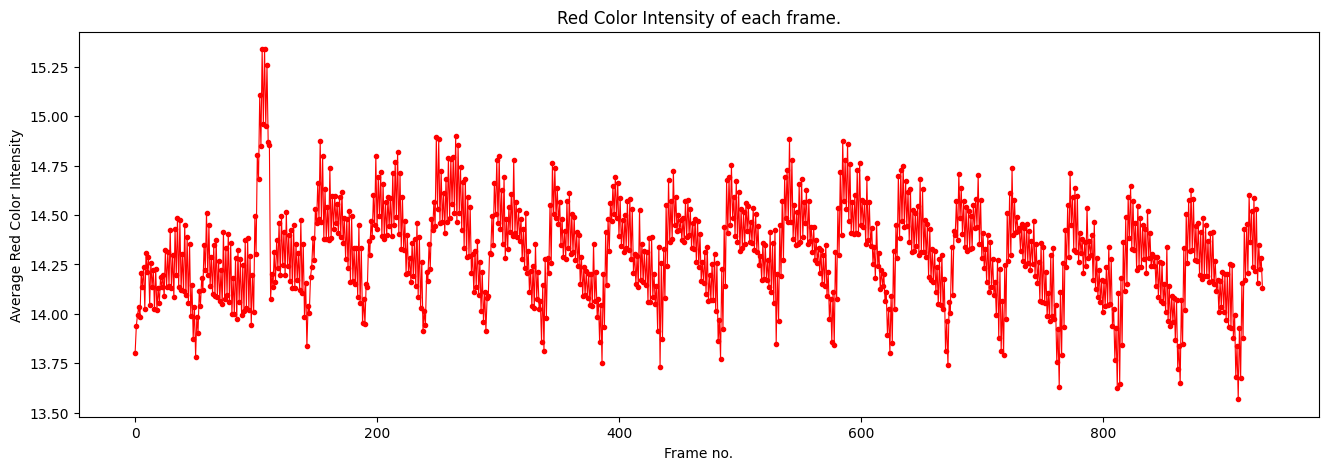

In [5]:
# Total number of frames.
no_frames = len(frames)

# Dimension of each RGB pixel
n_row = frames[0].shape[0]
n_col = frames[0].shape[1]

# Variable for storing intensity of each pixel.
frame_intent_values = np.zeros(no_frames)

for ith_frame in range(no_frames):

    # Extracting Red, Green and Blue channel values of a particular location of each frame.
    frame = frames[ith_frame]
    average_red_channel = np.mean(frame[:, :, 0])

    # Calculating intensity using formula.
    # frame_intensity = 0.299 * red_channel + 0.587 * green_channel + 0.114 * blue_channel
    frame_intensity = average_red_channel
    frame_intent_values[ith_frame] = frame_intensity

# Plotting intensity values against each frame.
plt.figure(figsize=(16, 5))
plt.plot(frame_intent_values, color='red', linewidth=0.8, marker='.')
plt.title("Red Color Intensity of each frame.")
plt.xlabel("Frame no.")
plt.ylabel("Average Red Color Intensity")
plt.savefig('intensityGraph.png')
plt.show()

## Fast Fourier Transform of intensity values of each frames.

Calculated Heart Rate: 73.3 BPM


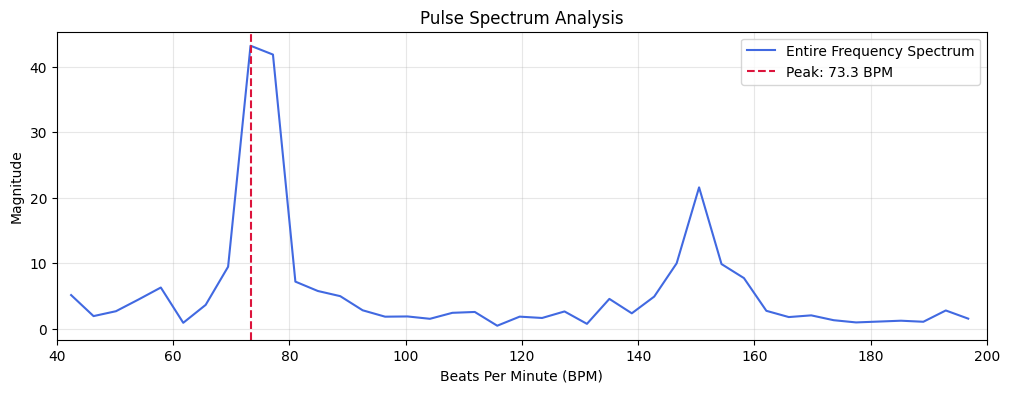

In [6]:
"""
Video Acquisition Device Specifications
Apple iPhone 11.
FPS = 60 frames/sec @ 1080p HD
"""

Fs = 60.0
Ts = 1 / Fs
min_bpm, max_bpm = 40.0, 200.0
m = len(frame_intent_values)

# Zero out the steady flashlight baseline (DC offset)
intensity_detrended = frame_intent_values - np.mean(frame_intent_values)

# Aligning edges with a Hamming window to prevent frequency leakage
windowed_signal = intensity_detrended * windows.hamming(m)

# Compute Real FFT and translate Hz to Beats Per Minute (BPM)
fft_magnitudes = np.abs(np.fft.rfft(windowed_signal))
frequencies_bpm = np.fft.rfftfreq(m, d=Ts) * 60.0

# Restricting frequency range to valid physiological heart rates
valid_idx = np.where((frequencies_bpm >= min_bpm) & (frequencies_bpm <= max_bpm))[0]
bpm_range = frequencies_bpm[valid_idx]
fft_range = fft_magnitudes[valid_idx]

# Extracting dominant pulse frequency
max_peak_idx = np.argmax(fft_range)
estimated_heart_rate = bpm_range[max_peak_idx]

print(f"Calculated Heart Rate: {estimated_heart_rate:.1f} BPM")

# Plotting the full frequency spectrum and identifying the peak heart rate frequency.
plt.figure(figsize=(12, 4))
plt.plot(bpm_range, fft_range, color='royalblue', linewidth=1.5, label='Entire Frequency Spectrum')
plt.axvline(x=estimated_heart_rate, color='crimson', linestyle='--', label=f'Peak: {estimated_heart_rate:.1f} BPM')
plt.title('Pulse Spectrum Analysis')
plt.xlabel('Beats Per Minute (BPM)')
plt.ylabel('Magnitude')
plt.xlim(min_bpm, max_bpm)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('spectrumAnalysis.png')
plt.show()

## Estimated Heartbeat per Minute

The dominant frequency component of the pulse signal is clearly identified at **73.3 BPM**, represented by the sharpest and highest peak with a magnitude of over 40. This indicates that the subject's resting heart rate is approximately 73 BPM, which falls well within the normal healthy resting range (60–100 BPM).

## Blood Oxygen Level

To estimate blood oxygen saturation ($\text{SpO}_2$) using your smartphone data, you have to calculate what is known in biomedical engineering as the "**Ratio-of-Ratios**" (often called the $R$-value). We have to extract the alternating pulse signal (AC) and the static baseline intensity (DC) for both the Red and Green color channels.

Mathematically,

$$R = \frac{\left( \frac{\text{AC}_{\text{Red}}}{\text{DC}_{\text{Red}}} \right)}{\left( \frac{\text{AC}_{\text{Green}}}{\text{DC}_{\text{Green}}} \right)}$$

Empirical Calibration Linear Formula

$$\text{SpO}_2 = A - (B \cdot R)$$

But here we are taking the ratio of mean red channel value of frame to mean green channel value of frame to get a rough idea about blood oxygen level.

Python function to evaluate $\mathrm{SpO_2}$

In [36]:
def estimate_spo2(frames):
    frame = frames[1]
    avg_red = np.mean(frame[:, :, 2])
    avg_green = np.mean(frame[:, :, 1])

    # Avoiding zero division error.
    if avg_green == 0:
        if avg_red > 180:
            avg_green = avg_green + 2

    ratio = avg_red / avg_green
    
    # SpO2 estimation formula
    spo2 = avg_red / avg_green
    
    return min(100.0, max(0.0, spo2))

In [37]:
print(f"Blood Oxgyen Level: {estimate_spo2(frames):.2f}")

Blood Oxgyen Level: 95.63


## Error Analysis

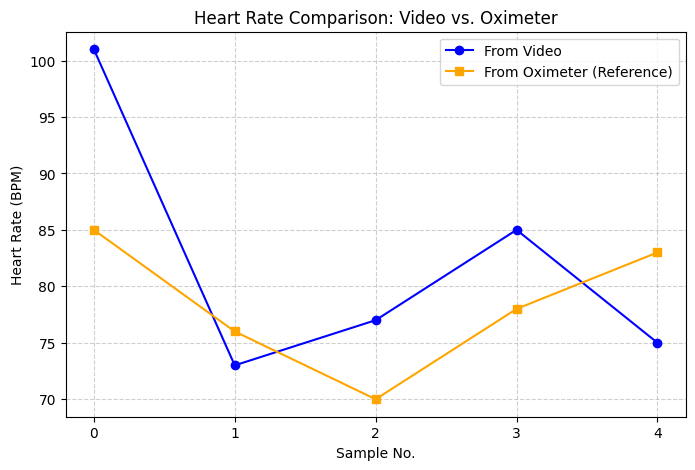

In [28]:

count = list(range(5)) 
beat_video = np.array([101, 73, 77, 85, 75])
beat_oximeter = np.array([85, 76, 70, 78, 83])


err = beat_video - beat_oximeter
err_mean = np.mean(err)
err_std = np.std(err)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(count, beat_video, marker='o', label='From Video', color='blue')
plt.plot(count, beat_oximeter, marker='s', label='From Oximeter (Reference)', color='orange')
# plt.axhline(y=err_mean, color='red', linestyle='--', label='Mean Error')

# Formatting
plt.title('Heart Rate Comparison: Video vs. Oximeter')
plt.xlabel('Sample No.')
plt.ylabel('Heart Rate (BPM)')
plt.xticks(count)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.savefig('errorComparison_Beat.png')
plt.show()

In [26]:
print(err_mean, err_std)

3.8 8.423775875461075


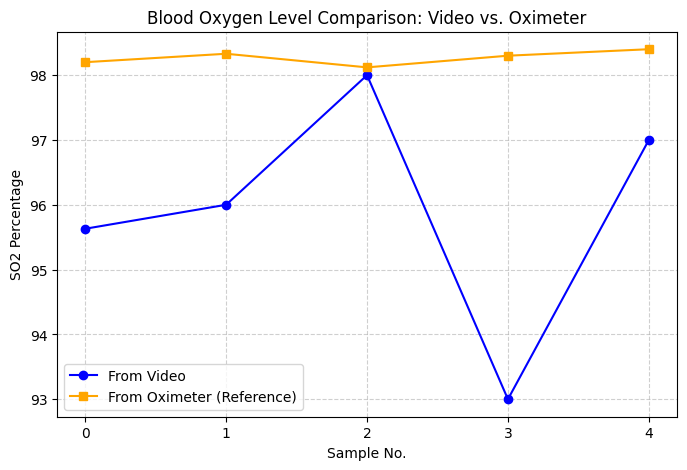

In [33]:
count = list(range(5)) 
so2_video = np.array([95.63, 96, 98, 93, 97])
so2_oximeter = np.array([98.2, 98.33, 98.12, 98.3, 98.4])

err = so2_video - so2_oximeter
so2_err_mean = np.mean(err)
so2_err_std = np.std(err)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(count, so2_video, marker='o', label='From Video', color='blue')
plt.plot(count, so2_oximeter, marker='s', label='From Oximeter (Reference)', color='orange')
# plt.axhline(y=err_mean, color='red', linestyle='--', label='Mean Error')

# Formatting
plt.title('Blood Oxygen Level Comparison: Video vs. Oximeter')
plt.xlabel('Sample No.')
plt.ylabel('SO2 Percentage')
plt.xticks(count)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.savefig('errorComparison_oxygen.png')
plt.show()

In [34]:
print(so2_err_mean, so2_err_std)

-2.3440000000000025 1.7103520105522112
